<b><h2>Mask - No Mask code

In [3]:
## Importing libraries
import pandas as pd
import numpy as np
import cv2
import os
import glob
from scipy.spatial import distance
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from keras import Sequential, models
from keras.layers import Flatten, Dense, Conv2D, MaxPool2D
from keras.preprocessing.image import ImageDataGenerator

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
maskpath = "./Data/data/with_mask/"
nomaskpath = "./Data/data/without_mask/"

In [5]:
dataset={
    "imgpath":[],
    "mask_status":[]
}

for i in os.listdir(maskpath):
    dataset['imgpath'].append(f'./Data/data/with_mask/{i}')
    dataset["mask_status"].append('Mask')

for i in os.listdir(nomaskpath):
    dataset['imgpath'].append(f'./Data/data/without_mask/{i}')
    dataset["mask_status"].append('NoMask')


In [6]:
df = pd.DataFrame(dataset,index=[ i for i in range(1,7554)])
df

,imgpath,mask_status
1,./Data/data/with_mask/with_mask_1.jpg,Mask
2,./Data/data/with_mask/with_mask_10.jpg,Mask
3,./Data/data/with_mask/with_mask_100.jpg,Mask
4,./Data/data/with_mask/with_mask_1000.jpg,Mask
5,./Data/data/with_mask/with_mask_1001.jpg,Mask
...,...,...
7549,./Data/data/without_mask/without_mask_995.jpg,NoMask
7550,./Data/data/without_mask/without_mask_996.jpg,NoMask
7551,./Data/data/without_mask/without_mask_997.jpg,NoMask
7552,./Data/data/without_mask/without_mask_998.jpg,NoMask


In [55]:
df = df.sample(frac=1).reset_index(drop=True)

In [57]:
df['mask_status'].value_counts()

NoMask    3828
Mask      3725
Name: mask_status, dtype: int64

In [60]:
import pandas as pd
from sklearn.model_selection import train_test_split
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.applications import VGG16
from keras.callbacks import EarlyStopping


# Load dataset
data = df  # Replace 'your_dataset.csv' with your actual dataset path
img_width, img_height = 150, 150
# Data augmentation and preprocessing
datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    rotation_range=20,  # Add rotation
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.2
)



train_generator = datagen.flow_from_dataframe(dataframe=data, x_col='imgpath', y_col='mask_status',
                                              subset='training', batch_size=32, shuffle=True,
                                              target_size=(150, 150))

test_generator = datagen.flow_from_dataframe(dataframe=data, x_col='imgpath', y_col='mask_status',
                                             subset='validation', batch_size=32, shuffle=True,
                                             target_size=(150, 150))

# Load the VGG16 model without the fully connected layers (include_top=False)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze the pre-trained layers
for layer in base_model.layers[:-3]:  # Unfreeze top 3 layers
    layer.trainable = False


# Create the Sequential model
model = Sequential()

# Convolutional layers
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

# Flattening the output
model.add(Flatten())

# Dense layers
model.add(Dense(128, activation='relu'))
model.add(Dense(2, activation='softmax'))
    

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
early_stopping = EarlyStopping(monitor='val_loss', patience=3)

history = model.fit(train_generator, steps_per_epoch=len(train_generator), epochs=10,
                    validation_data=test_generator, validation_steps=len(test_generator),callbacks=[early_stopping])

# Evaluate the model
model.evaluate(test_generator)

# [0.11382268369197845, 0.9596026539802551] filters are 16 48 64
# [0.2573868930339813, 0.9066225290298462] filters are 16 48 64
# [0.16565144062042236, 0.9370861053466797]

Found 6043 validated image filenames belonging to 2 classes.
Found 1510 validated image filenames belonging to 2 classes.
Epoch 1/10
  2/189 [..............................] - ETA: 1:18 - loss: 0.9993 - accuracy: 0.4688 

c:\Users\aksha\AppData\Local\Programs\Python\Python39\lib\site-packages\PIL\Image.py:975: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


189/189 [==============================] - 105s 533ms/step - loss: 0.4054 - accuracy: 0.8130 - val_loss: 0.2946 - val_accuracy: 0.8828
Epoch 2/10
189/189 [==============================] - 90s 474ms/step - loss: 0.2827 - accuracy: 0.8835 - val_loss: 0.2578 - val_accuracy: 0.8874
Epoch 3/10
189/189 [==============================] - 90s 477ms/step - loss: 0.2505 - accuracy: 0.8994 - val_loss: 0.2220 - val_accuracy: 0.9126
Epoch 4/10
189/189 [==============================] - 90s 477ms/step - loss: 0.2245 - accuracy: 0.9073 - val_loss: 0.3004 - val_accuracy: 0.9000
Epoch 5/10
189/189 [==============================] - 89s 471ms/step - loss: 0.2085 - accuracy: 0.9169 - val_loss: 0.2474 - val_accuracy: 0.9053
Epoch 6/10
189/189 [==============================] - 88s 466ms/step - loss: 0.1957 - accuracy: 0.9269 - val_loss: 0.2070 - val_accuracy: 0.9219
Epoch 7/10
189/189 [==============================] - 90s 474ms/step - loss: 0.1786 - accuracy: 0.9310 - val_loss: 0.1698 - val_accuracy: 0.

[0.16565144062042236, 0.9370861053466797]

In [61]:
model.summary()

Model: "sequential_28"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_84 (Conv2D)          (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d_84 (MaxPooli  (None, 74, 74, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_85 (Conv2D)          (None, 72, 72, 64)        18496     
                                                                 
 max_pooling2d_85 (MaxPooli  (None, 36, 36, 64)        0         
 ng2D)                                                           
                                                                 
 conv2d_86 (Conv2D)          (None, 34, 34, 128)       73856     
                                                                 
 max_pooling2d_86 (MaxPooli  (None, 17, 17, 128)     

In [3]:
def plot_loss_and_accuracy(history):
    history_df = pd.DataFrame(history)
    fig, ax = plt.subplots(1,2, figsize=(12, 6))
    
    history_df.loc[0:, ['loss', 'val_loss']].plot(ax=ax[0])
    ax[0].set(xlabel = 'epoch number', ylabel = 'loss')

    history_df.loc[0:, ['accuracy', 'val_accuracy']].plot(ax=ax[1])
    ax[1].set(xlabel = 'epoch number', ylabel = 'accuracy')

In [4]:
plot_loss_and_accuracy(history.history)

NameError: name 'history' is not defined

In [64]:
# Save the entire model to a HDF5 file
model.save('mask_detection_model.h5')


c:\Users\aksha\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [65]:
# Save the model architecture as JSON
model_json = model.to_json()
with open('mask_detection_model.json', 'w') as json_file:
    json_file.write(model_json)

# Save model weights
model.save_weights('mask_detection_model_weights.h5')


1/1 [==============================] - 0s 67ms/step


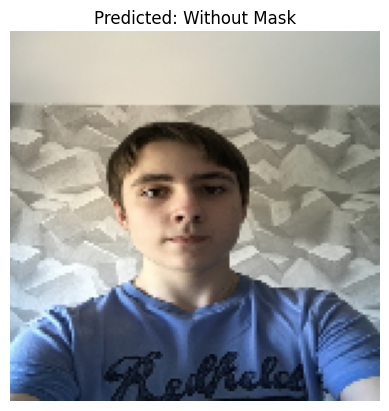

In [5]:
from keras.models import load_model
from keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np

# Load the trained model
model = load_model('mask_detection_model.h5')  # Load your saved model

# Load and preprocess the new image
img_path = './Data/images/maksssksksss837.png'  # Replace with the path to your image
img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array /= 255.0  # Normalize pixel values

# Make predictions
prediction = model.predict(img_array)

# Interpret the prediction
predicted_class = "With Mask" if prediction[0][0] > 0.5 else "Without Mask"

# Display the image with the predicted class
plt.imshow(img)
plt.title(f'Predicted: {predicted_class}')
plt.axis('off')  # Hide axis
plt.show()


<h2><b>To get the Realtime Predictions on Cam

In [ ]:
import cv2
import numpy as np
from keras.models import load_model
from keras.preprocessing import image
import time

# Load the trained model
model = load_model('mask_detection_model.h5')  # Load your trained model

# Access the camera (change the index if you have multiple cameras)
cap = cv2.VideoCapture(0)

label = "Initializing..."  # Initialize label variable

while True:
    # Capture frame-by-frame
    ret, frame = cap.read()
    
    # Preprocess the frame (resize, normalize)
    frame_resized = cv2.resize(frame, (150, 150))
    frame_resized = frame_resized / 255.0  # Normalize pixel values
    
    # Convert frame to array
    img_array = np.expand_dims(frame_resized, axis=0)
    
    # Make predictions every 5 seconds
    if time.time() % 5 < 0.1:  # Update every 5 seconds
        prediction = model.predict(img_array)
        
        # Interpret the prediction
        if prediction[0][0] > 0.5:  # Assuming binary classification (mask/no-mask)
            label = "With Mask"
        else:
            label = "Without Mask"
    
    # Display prediction on the frame
    cv2.putText(frame, label, (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    
    # Display the frame with predictions
    cv2.imshow('Mask Detection', frame)
    
    # Press 'q' to exit the loop
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the camera and close all OpenCV windows
cap.release()
cv2.destroyAllWindows()